In [9]:
import pandas as pd 
from pandas import CategoricalDtype 
import numpy as np
import sqlite3
import plotnine as pm
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [10]:
apt_per_phase = pd.read_csv('/kaggle/input/datasets/micahluftig/from-sql-joins/avg_appt_per_moonphase.csv')
p_data = pd.read_csv('/kaggle/input/datasets/micahluftig/from-sql-joins/p_data.csv')
apt_data = pd.read_csv('/kaggle/input/datasets/micahluftig/from-sql-joins/apt_data.csv')
weather_y_apts_per_day = pd.read_csv('/kaggle/input/datasets/micahluftig/dasaxz/other_environmental_variables.csv')

In [11]:
def table_check(df, df_name) -> pd.DataFrame:
    '''
    Checks and prints the count of null (NaN) values for every column in a Pandas DataFrame.
    '''
    header()
    print(f'Beginning errorcheck for: {df_name} ***')
    print(f'\n--- Null Value Check ---')
    for column in df.columns: 
        null_count = df[column].isna().sum() 
        print(f'{column} nulls: {null_count}')
    print('\n')
    
    print(f'--- Integrity Check ---')
    if 'appointment_id' in df.columns:
        duplicate_count = df['appointment_id'].duplicated().sum()
        print(f'Total appointment_id duplicates: {duplicate_count}')
    else:
        print("WARNING: 'appointment_id' not found for duplication check.")
    print('\n')
    print(f'\n--- Data Type Audit (DF.dtypes) ---')
    print(df.dtypes)
    
    print(f'\n--- Numerical Sanity Check (DF.describe) ---')
    
    numeric_cols = df.select_dtypes(include = ['int64', 'float64', 'Int64', 'int32']).columns
    if not numeric_cols.empty:
        print(df[numeric_cols].describe())
    else:
        print('No standard numerical columns found for description.')

    print(f'\n--- Categorical Value Audit (Top 10 Counts) ---')
    object_cols = df.select_dtypes(include=['object']).columns

    for column in object_cols:
        print(f'\n{column.upper()}:')
        print(df[column].value_counts().nlargest(10))
    
    print('\n\n\n')
    
    return df

def normality_test(df, y_axis, x_axis):
    
    df_clean = df.dropna(subset=[y_axis, x_axis]).copy()
    
    transformations = {
        f'Regular ({y_axis})': df_clean[y_axis],
        f'Log (log({y_axis} + 0.001))': np.log(df_clean[y_axis] + 0.001),
        f'Sqrt (sqrt({y_axis}))': np.sqrt(df_clean[y_axis]),
        f'Log-Sqrt (log(sqrt({y_axis}) + 0.001))': np.log(np.sqrt(df_clean[y_axis]) + 0.001)
    }
    
    print('=' * 50)
    print(f'{y_axis} by {x_axis}\n\n')
    
    
    for label, y_values in transformations.items():
        
        df_clean['temp_y'] = y_values
        residuals = smf.ols(f'temp_y ~ {x_axis}', data=df_clean).fit().resid
        stat, p_val = stats.shapiro(residuals)
        
        
        print(f'{label}')
        print(f'Transformation: {label}')
        print(f'  W = {stat:.5f}, p-value = {p_val:.5e}\n')
        
    print('=' * 50)
    return df



def normality_plot(df, y_axis):
    epsilon = 0.001
    y_clean = df[y_axis].dropna()
    
    fig, axes = plt.subplots(2, 2, figsize=(8, 5))
    
    
    transformations = [
        ('regular', y_clean),
        ('sqrt', np.sqrt(y_clean)),
        ('log', np.log(y_clean + epsilon)),
        ('log(sqrt)', np.log(np.sqrt(y_clean) + epsilon))
    ]
    
   
    for (title, y_values), ax in zip(transformations, axes.flat):
        stats.probplot(y_values, plot=ax)
        ax.set_title(f'Normal Q-Q: {title}')
    plt.tight_layout()
    plt.show()
    
    return df

def kruskal_wallis(df, y_axis, x_axis):
    # 1. Gather the data groups in one clean line
    groups = [group[y_axis] for name, group in df.groupby(x_axis, observed = False)]
    
    # 2. Run the test
    stat, p_val = stats.kruskal(*groups)
    
    # 3. Print the results
    print('=' * 50)
    print(f'Kruskal-Wallis rank sum test')
    print(f'Data: {y_axis} by {x_axis}')
    print(f'  Chi-squared = {stat:.5f}, p-value = {p_val:.5e}')
    print('=' * 50)
    
    return df


def intake_per_moon(df) -> pd.DataFrame:
    return (df
            .pipe(normality_test,'avg_daily_intakes', 'moonphase')
            .pipe(normality_plot,'avg_daily_intakes')
            .pipe(kruskal_wallis, 'avg_daily_intakes', 'moonphase')
    )

def deceased_per_moon(df) -> pd.DataFrame:
    return (df
            .pipe(normality_test,'avg_p_deceased', 'moonphase')
            .pipe(normality_plot,'avg_p_deceased')
            .pipe(kruskal_wallis, 'avg_p_deceased', 'moonphase')
    )

avg_daily_intakes by moonphase


Regular (avg_daily_intakes)
Transformation: Regular (avg_daily_intakes)
  W = 0.81268, p-value = 6.21384e-08

Log (log(avg_daily_intakes + 0.001))
Transformation: Log (log(avg_daily_intakes + 0.001))
  W = 0.74253, p-value = 1.12772e-09

Sqrt (sqrt(avg_daily_intakes))
Transformation: Sqrt (sqrt(avg_daily_intakes))
  W = 0.78843, p-value = 1.41534e-08

Log-Sqrt (log(sqrt(avg_daily_intakes) + 0.001))
Transformation: Log-Sqrt (log(sqrt(avg_daily_intakes) + 0.001))
  W = 0.74254, p-value = 1.12814e-09



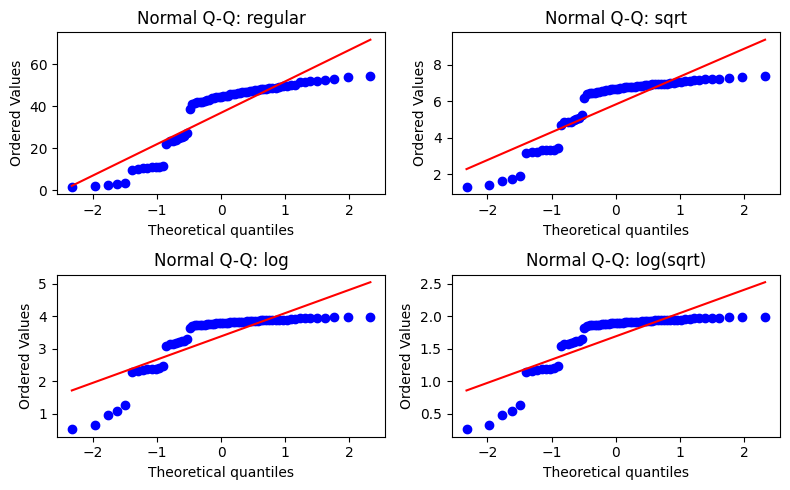

Kruskal-Wallis rank sum test
Data: avg_daily_intakes by moonphase
  Chi-squared = 0.95068, p-value = 9.95585e-01


In [12]:
intake_per_moon_output = intake_per_moon(apt_per_phase)

In [13]:
def plot_moon_phases(df, y_axis, title_text):
    
    phase_order = [
        'new_moon', 'waxing_crescent', 'first_quarter', 'waxing_gibbous', 
        'full', 'waning_gibbous', 'third_quarter', 'waning_crescent'
    ]
    
    
    df_clean = df.copy()
    moon_category = CategoricalDtype(categories=phase_order, ordered=True)
    df_clean['moonphase'] = df_clean['moonphase'].astype(moon_category)
    
    
    p = (
        pm.ggplot(df_clean, pm.aes(x = 'moonphase', y = y_axis)) 
        + pm.geom_col(fill='lightblue') 
        + pm.theme_minimal() 
        + pm.theme(axis_text_x = pm.element_text(angle=45, hjust=1)) 
        + pm.labs(
            title=title_text, 
            subtitle = 'Veterinary Nurse Analysis of Shelter Data Over 6 years'
        )
    )
    return p




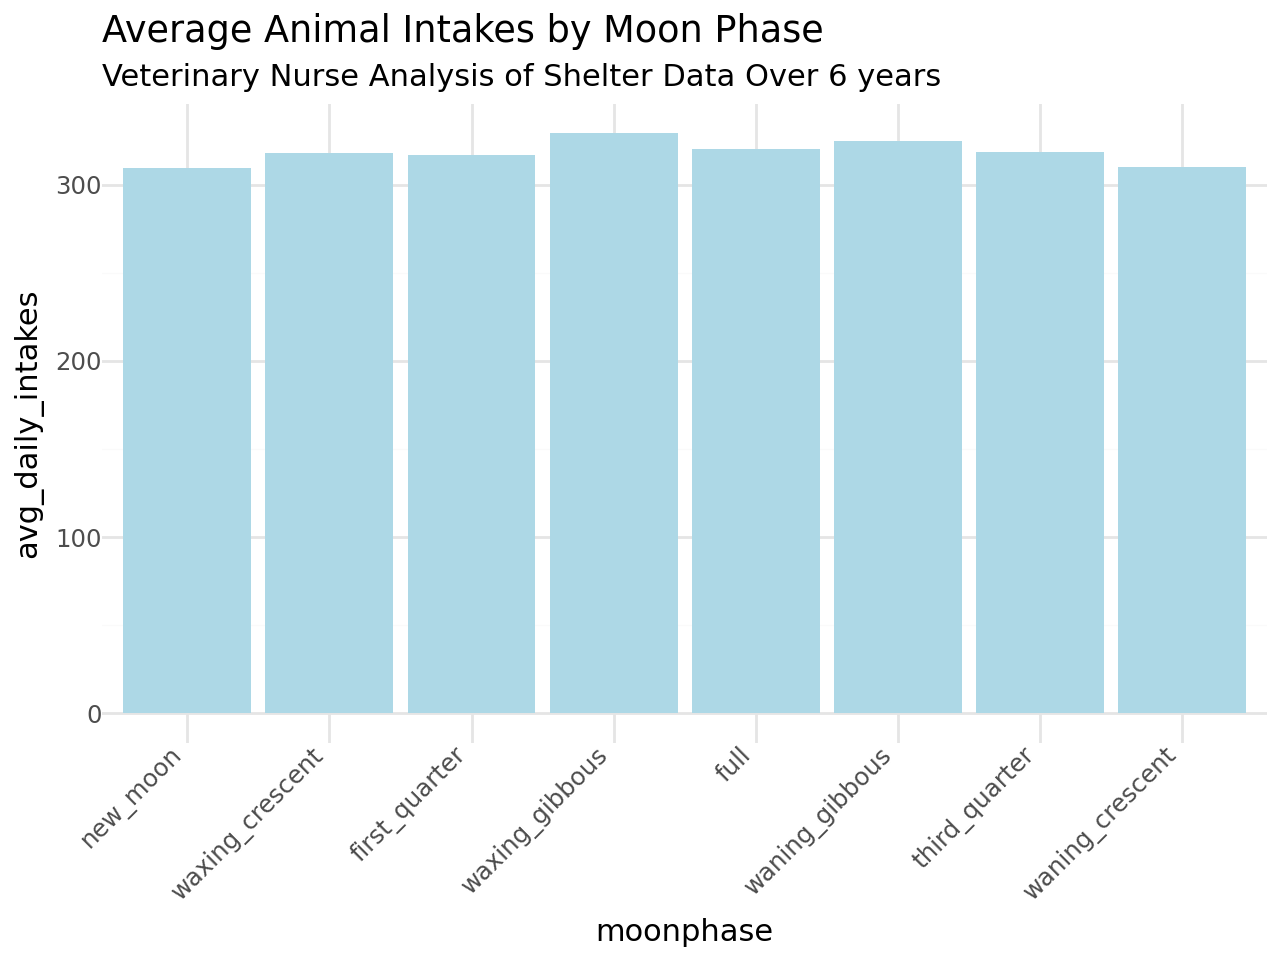

In [14]:
plot_moon_phases(intake_per_moon_output, 'avg_daily_intakes', 'Average Animal Intakes by Moon Phase')

avg_p_deceased by moonphase


Regular (avg_p_deceased)
Transformation: Regular (avg_p_deceased)
  W = 0.93256, p-value = 1.07920e-03

Log (log(avg_p_deceased + 0.001))
Transformation: Log (log(avg_p_deceased + 0.001))
  W = 0.85101, p-value = 8.35600e-07

Sqrt (sqrt(avg_p_deceased))
Transformation: Sqrt (sqrt(avg_p_deceased))
  W = 0.96178, p-value = 3.33768e-02

Log-Sqrt (log(sqrt(avg_p_deceased) + 0.001))
Transformation: Log-Sqrt (log(sqrt(avg_p_deceased) + 0.001))
  W = 0.85035, p-value = 7.96477e-07



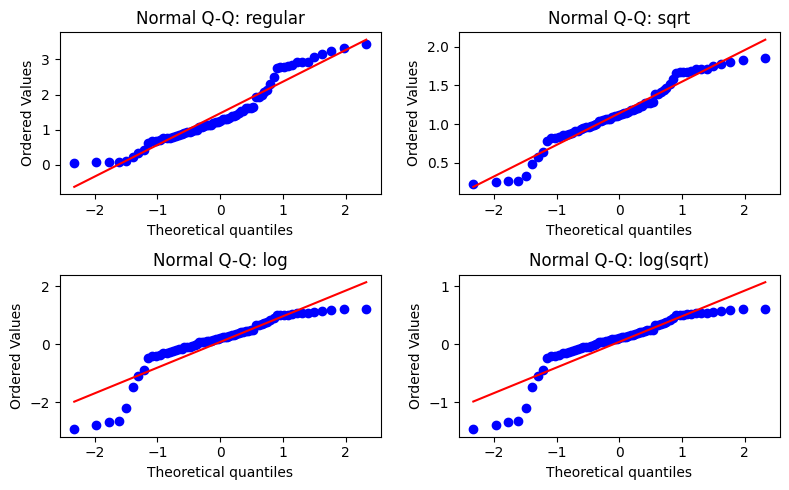

Kruskal-Wallis rank sum test
Data: avg_p_deceased by moonphase
  Chi-squared = 0.68243, p-value = 9.98467e-01


In [15]:
deceased_per_moon_output = deceased_per_moon(apt_per_phase)

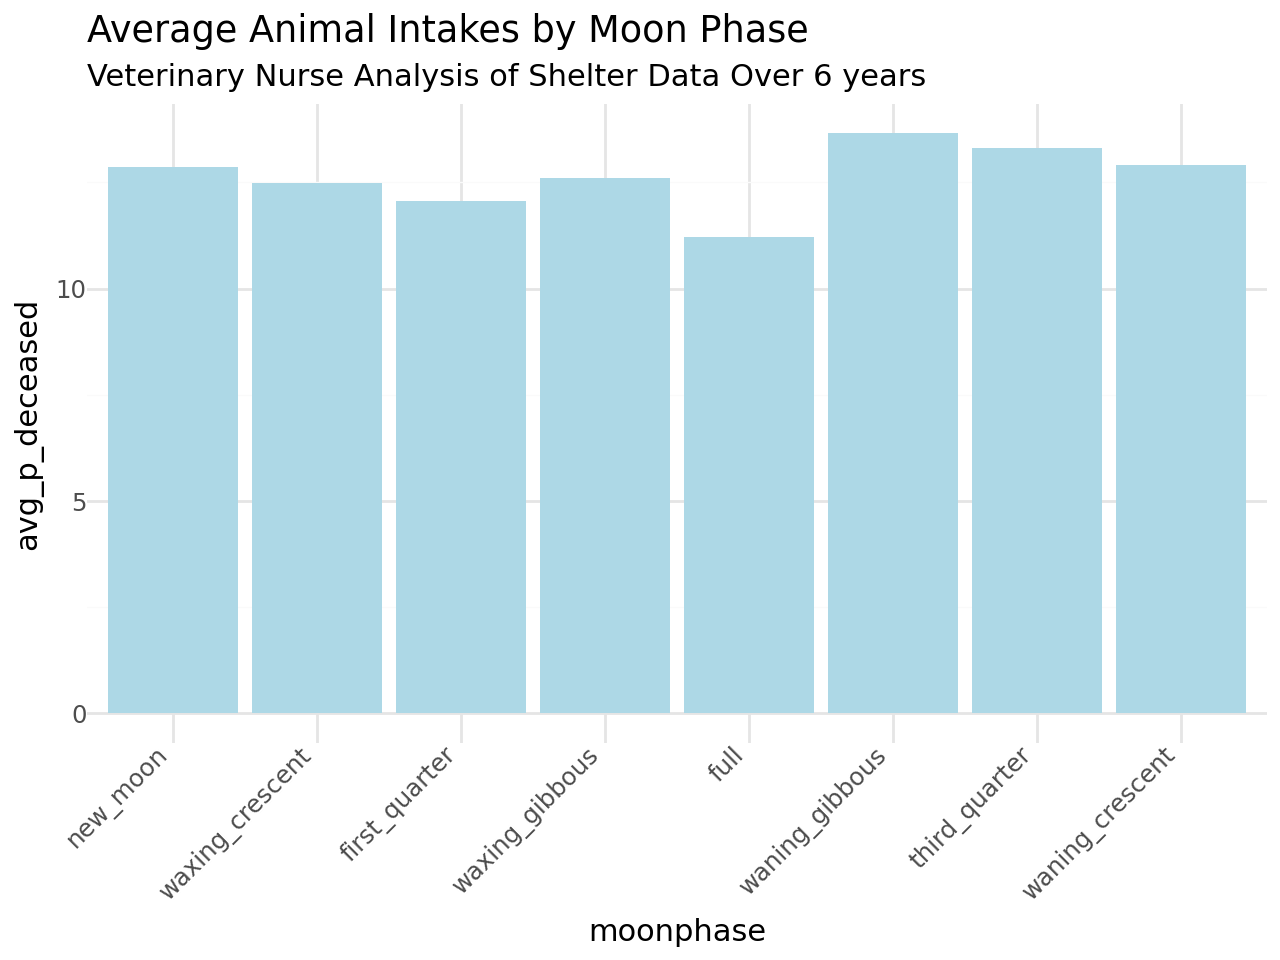

In [16]:
plot_moon_phases(intake_per_moon_output, 'avg_p_deceased', 'Average Animal Intakes by Moon Phase')

In [17]:
vars_to_plot = ['temp(\u00b0F)', 'feels_like(°F)', 'humidity(%)', 'precip(in)', 'wind_gust(mph)','wind_speed(mph)', 
                'sea_level_pressure(mb)','visibility(mi)', 'solar_radiation(W/m\u00b2)', 'solar_energy(MJ/m\u00b2)']

long_data = weather_y_apts_per_day.melt(id_vars=['apt_seen', 'p_deceased'], value_vars=vars_to_plot)


In [18]:
def plot_environmental_factors(df, y_axis, y_label_text, title_text):
    p = (
        pm.ggplot(df, pm.aes(x='value', y=y_axis)) 
        + pm.geom_point(alpha=0.5, color='steelblue') 
        + pm.geom_smooth(method='lm', color='firebrick', se=True) 
        + pm.facet_wrap('~variable', scales='free_x', ncol=2) 
        + pm.labs(
            title = title_text, 
            x = 'Metric Value', 
            y = y_label_text
        ) 
        + pm.theme_minimal()
    )
    return p

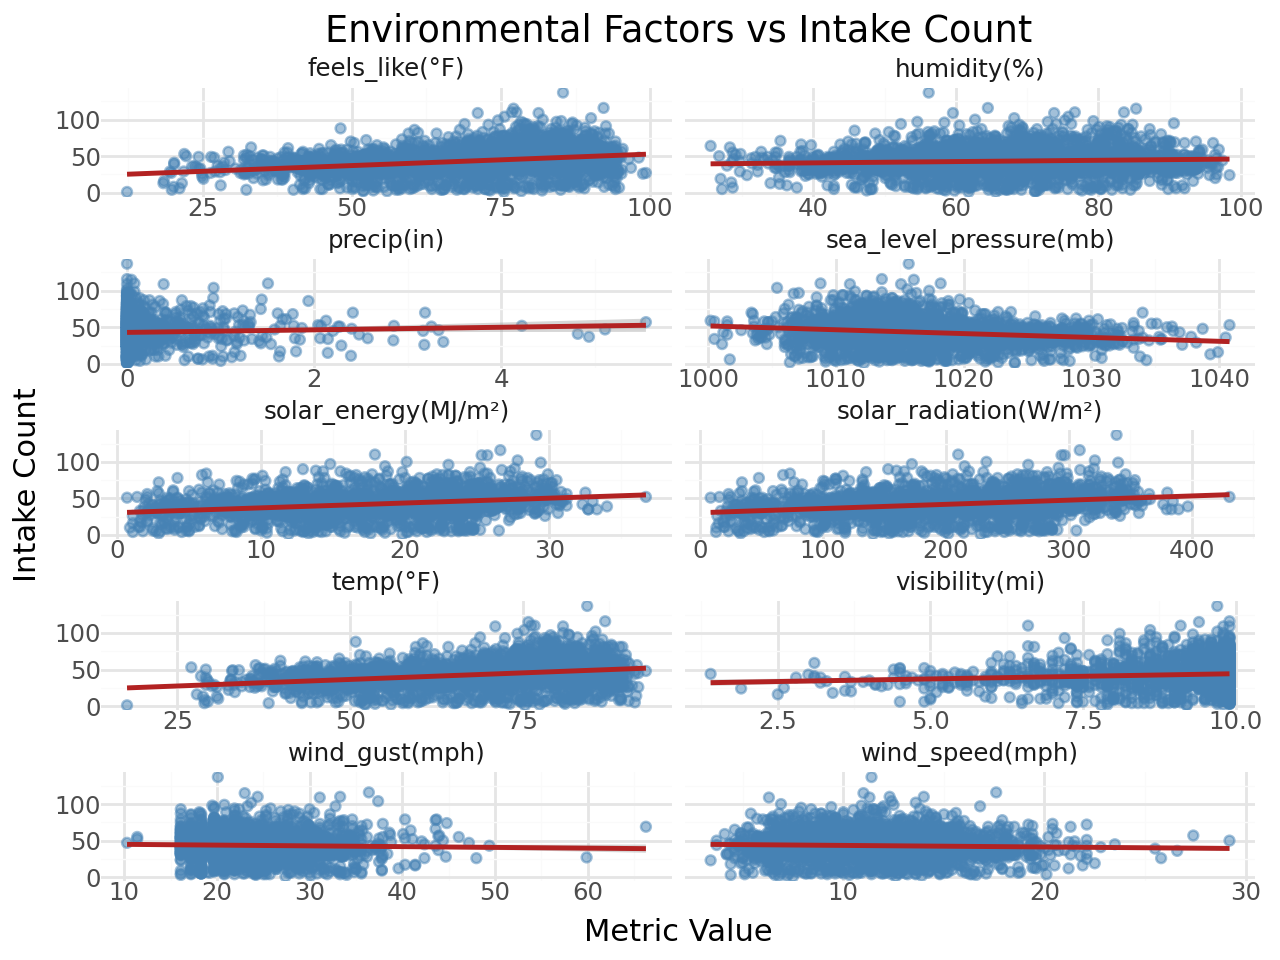

In [19]:
plot_environmental_factors(
    long_data, 
    y_axis = 'apt_seen', 
    y_label_text = 'Intake Count', 
    title_text = 'Environmental Factors vs Intake Count'
)

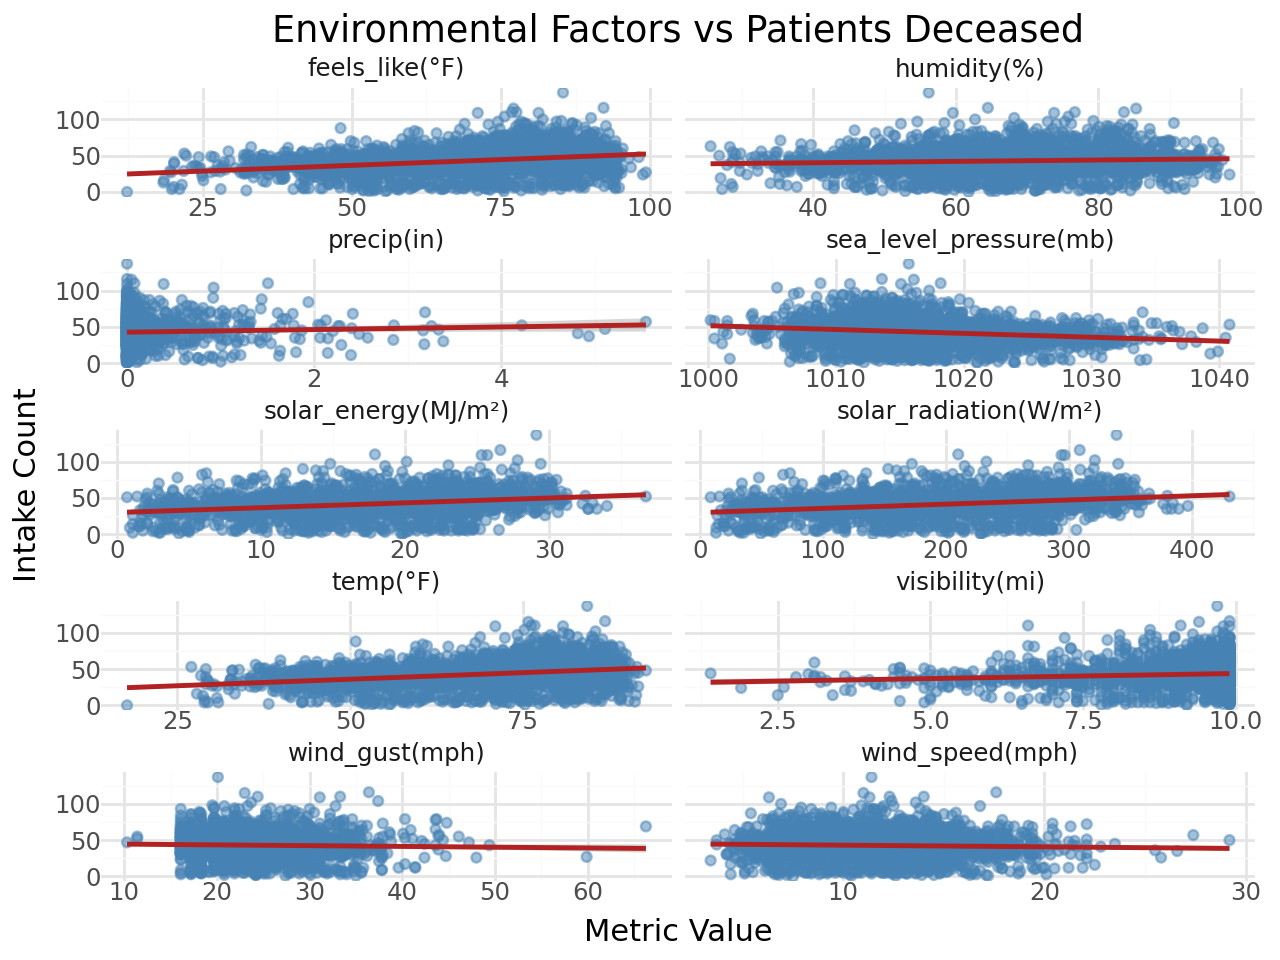

In [20]:
plot_environmental_factors(
    long_data, 
    y_axis='p_deceased', 
    y_label_text='Intake Count', 
    title_text='Environmental Factors vs Patients Deceased'
)

In [21]:
def scatter_slopes(df):
    df_clean = df.dropna(subset=['value', 'apt_seen', 'p_deceased'])

    slopes = (df_clean.groupby('variable', observed=False)
              .apply(lambda g: pd.Series({
                  'apt_slope': stats.linregress(g['value'], g['apt_seen']).slope,
                  'apt_p_value': stats.linregress(g['value'], g['apt_seen']).pvalue,
                  'deceased_slope': stats.linregress(g['value'], g['p_deceased']).slope,
                  'deceased_p_value': stats.linregress(g['value'], g['p_deceased']).pvalue
              }), include_groups=False)
              .reset_index())

    slopes = slopes.reindex(slopes['apt_slope'].abs().sort_values(ascending = False).index)
    return(slopes)


In [22]:
p = scatter_slopes(long_data)
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
print(p)

                 variable  apt_slope   apt_p_value  deceased_slope  deceased_p_value
2              precip(in)   1.756304  3.743576e-02        1.795411      3.496615e-02
7          visibility(mi)   1.430023  4.382915e-07        1.398741      9.723320e-07
4     solar_energy(MJ/m²)   0.663202  3.151619e-33        0.667883      5.307348e-33
3  sea_level_pressure(mb)  -0.526960  7.459189e-22       -0.531399      7.738322e-22
6                temp(°F)   0.359337  1.556678e-56        0.361486      3.264423e-56
0          feels_like(°F)   0.314715  1.275256e-55        0.316630      2.572219e-55
9         wind_speed(mph)  -0.214603  2.498588e-02       -0.231528      1.650996e-02
8          wind_gust(mph)  -0.104329  1.262518e-01       -0.105759      1.240875e-01
1             humidity(%)   0.088858  2.949824e-04        0.094690      1.312672e-04
5   solar_radiation(W/m²)   0.057415  2.164779e-33        0.057811      3.740085e-33


In [23]:
comparison_results = []

for variable in long_data['variable'].unique():
    sub_df = long_data[long_data['variable'] == variable]
    
    # Run linear regression for appointments
    reg_apt = stats.linregress(sub_df['value'], sub_df['apt_seen'])
    m1, se1 = reg_apt.slope, reg_apt.stderr
    
    # Run linear regression for deceased patients
    reg_dec = stats.linregress(sub_df['value'], sub_df['p_deceased'])
    m2, se2 = reg_dec.slope, reg_dec.stderr
    
    # Calculate the Z-statistic and p-value for the difference between the slopes
    # Formula: Z = (Slope1 - Slope2) / Sqrt(SE1^2 + SE2^2)
    z_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat))) # Two-tailed test
    
    comparison_results.append({
        'variable': variable,
        'apt_slope': m1,
        'deceased_slope': m2,
        'z_statistic': z_stat,
        'p_value_of_difference': p_value
    })

# Convert to DataFrame and print
slope_comparison_df = pd.DataFrame(comparison_results)
pd.set_option('display.width', 1000)
print(slope_comparison_df)


                 variable  apt_slope  deceased_slope  z_statistic  p_value_of_difference
0                temp(°F)   0.359337        0.361486    -0.068290               0.945555
1          feels_like(°F)   0.314715        0.316630    -0.068840               0.945117
2             humidity(%)   0.088858        0.094690    -0.167490               0.866985
3              precip(in)   1.756304        1.795411    -0.032637               0.973964
4          wind_gust(mph)        NaN             NaN          NaN                    NaN
5         wind_speed(mph)  -0.214603       -0.231528     0.124540               0.900888
6  sea_level_pressure(mb)  -0.526960       -0.531399     0.057472               0.954169
7          visibility(mi)   1.430023        1.398741     0.077973               0.937850
8   solar_radiation(W/m²)        NaN             NaN          NaN                    NaN
9     solar_energy(MJ/m²)        NaN             NaN          NaN                    NaN


In [24]:
def plot_factor_vs_appointments(df, x_axis, y_axis, x_label_text, y_label_text, title_text, bin_size = 0.05):
    
    df_clean = df.dropna(subset=[x_axis, y_axis]).copy()

    if x_axis == 'precip(in)':
        df_clean = df_clean[df_clean['precip(in)'] > 0]
        
    p = (
        pm.ggplot(df_clean, pm.aes(x = x_axis, y = y_axis))
        + pm.stat_summary_bin(fun_y=np.mean, geom = 'bar', binwidth = bin_size, fill = 'steelblue', color = 'white')
        + pm.labs(
            x = x_label_text, 
            y = y_label_text, 
            title = title_text
        )
        + pm.theme_minimal()
    )
    return p


def format_p_value(val):
    if val < 0.00001:
        return f'{val:.5e}' 
    else:
        return f'{val:.5f}' 

def run_pairwise_wilcoxon(df, x_axis, y_axis, bins, labels, title_text):
    
    df_clean = df.dropna(subset=[x_axis, y_axis]).copy()
    scale_col = f'{x_axis}_scale'
    df_clean[scale_col] = pd.cut(df_clean[x_axis], bins = bins, labels = labels, ordered = True)
    
    
    groups = { 
        str(name): group[y_axis].to_numpy() 
        for name, group in df_clean.groupby(scale_col, observed = False)
    }
    
    
    # n * (n - 1)) / 2
    num_categories = len(labels)
    total_comparisons = int((num_categories * (num_categories - 1)) / 2)
    
    
    pairwise_results = []
    for i in range(num_categories):
        for j in range(i + 1, num_categories):
            g1, g2 = labels[i], labels[j]
            
            if g1 in groups and g2 in groups and len(groups[g1]) > 0 and len(groups[g2]) > 0:
                _, p_val = stats.mannwhitneyu(groups[g1], groups[g2], alternative='two-sided')
                
                
                p_adjusted = min(p_val * total_comparisons, 1.0)
                pairwise_results.append({'Comparison': f'{g1} vs {g2}', 'p-value (adj)': p_adjusted})
                
    
    results_df = pd.DataFrame(pairwise_results)
    
    results_df['p-value (adj)'] = results_df['p-value (adj)'].apply(format_p_value)
    
    
    print(f'--- Pairwise Wilcoxon Rank Sum Test ({title_text}) ---')
    print(f'{'Comparison':<45} | {'p-value (Adjusted)':<20}')
    print('-' * 70)
    
    for _, row in results_df.iterrows():
        print(f'{row['Comparison']:<45} | {row['p-value (adj)']:<20}')
    print('-' * 70)

def plot_weather_boxplot(df, x_axis, y_axis, bins, labels, title_text, x_label_text):
    
    df_plot = df.dropna(subset = [x_axis, y_axis]).copy()
    
    
    scale_col = f'{x_axis}_scale'
    df_plot[scale_col] = pd.cut(df_plot[x_axis], bins = bins, labels = labels, ordered = True)
    
    #  Set2 is colorblind-safe 
    p = (
        pm.ggplot(df_plot, pm.aes(x = scale_col, y = y_axis, fill = scale_col))
        + pm.geom_boxplot(color = '#333333', size = 1.0, fatten = 2)
        + pm.scale_fill_brewer(type = 'qual', palette = 'Set2') 
        + pm.theme_minimal()
        + pm.labs(
            title = title_text,
            x = x_label_text,
            y = 'Intake Count'
        )
    )
    return p




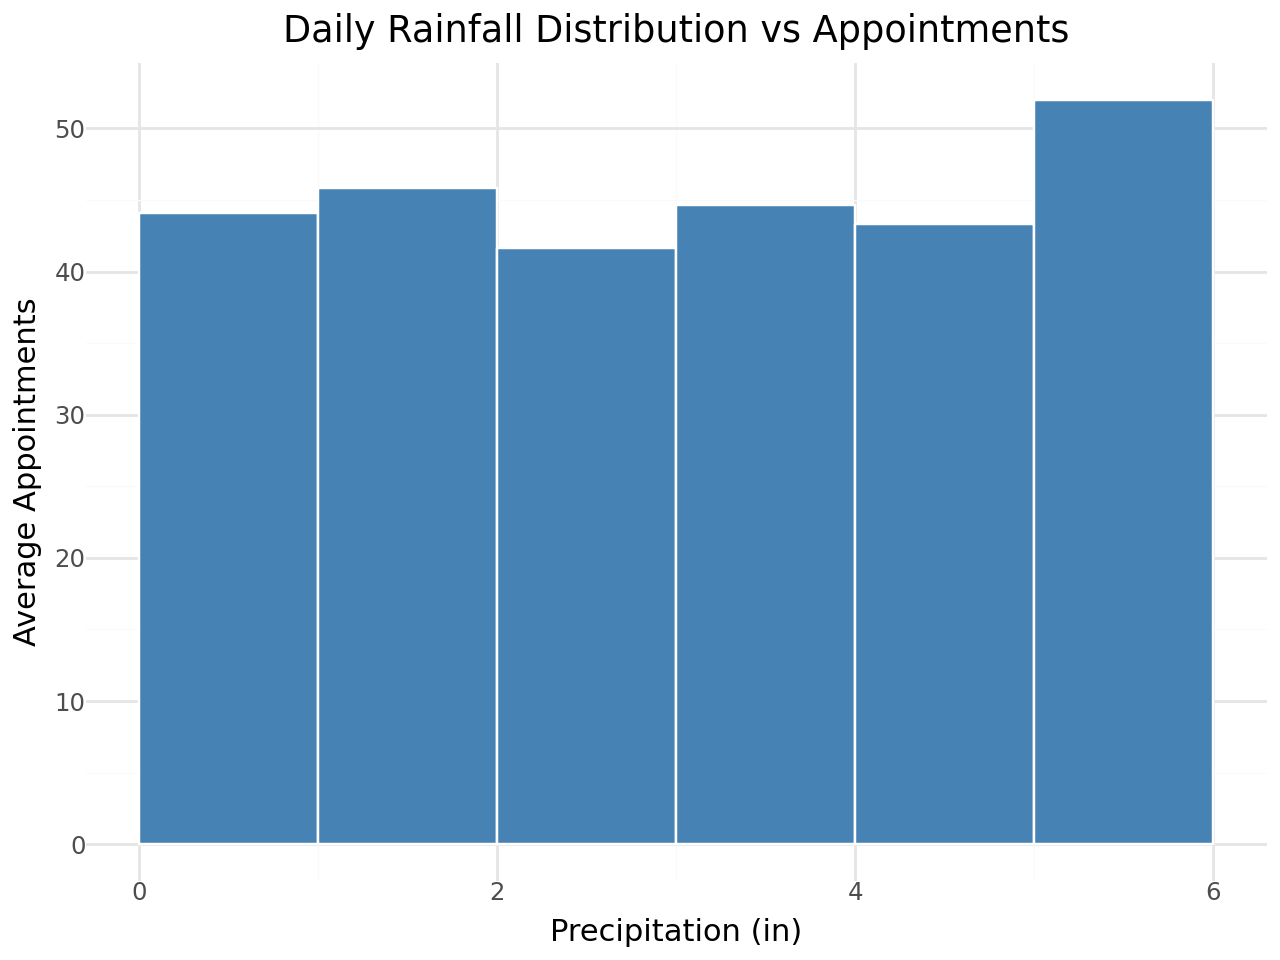

In [25]:
plot_factor_vs_appointments(
    weather_y_apts_per_day, 
    x_axis = 'precip(in)', 
    y_axis = 'apt_seen',
    x_label_text = 'Precipitation (in)',
    y_label_text = 'Average Appointments',
    title_text = 'Daily Rainfall Distribution vs Appointments',
    bin_size = 1
)


In [26]:
run_pairwise_wilcoxon(
    df=weather_y_apts_per_day,
    x_axis='precip(in)',
    y_axis='apt_seen',
    bins=[-0.001, 0, 0.1, 0.5, np.inf], # -0.001 floor safely captures exactly 0.0 inches
    labels=['None (0 in)', 'Light (0.01-0.10 in)', 'Moderate (0.11-0.50 in)', 'Heavy (>0.50 in)'],
    title_text='Rainfall Intensity'
)


--- Pairwise Wilcoxon Rank Sum Test (Rainfall Intensity) ---
Comparison                                    | p-value (Adjusted)  
----------------------------------------------------------------------
None (0 in) vs Light (0.01-0.10 in)           | 1.00000             
None (0 in) vs Moderate (0.11-0.50 in)        | 0.27418             
None (0 in) vs Heavy (>0.50 in)               | 0.03755             
Light (0.01-0.10 in) vs Moderate (0.11-0.50 in) | 0.35460             
Light (0.01-0.10 in) vs Heavy (>0.50 in)      | 0.06142             
Moderate (0.11-0.50 in) vs Heavy (>0.50 in)   | 1.00000             
----------------------------------------------------------------------


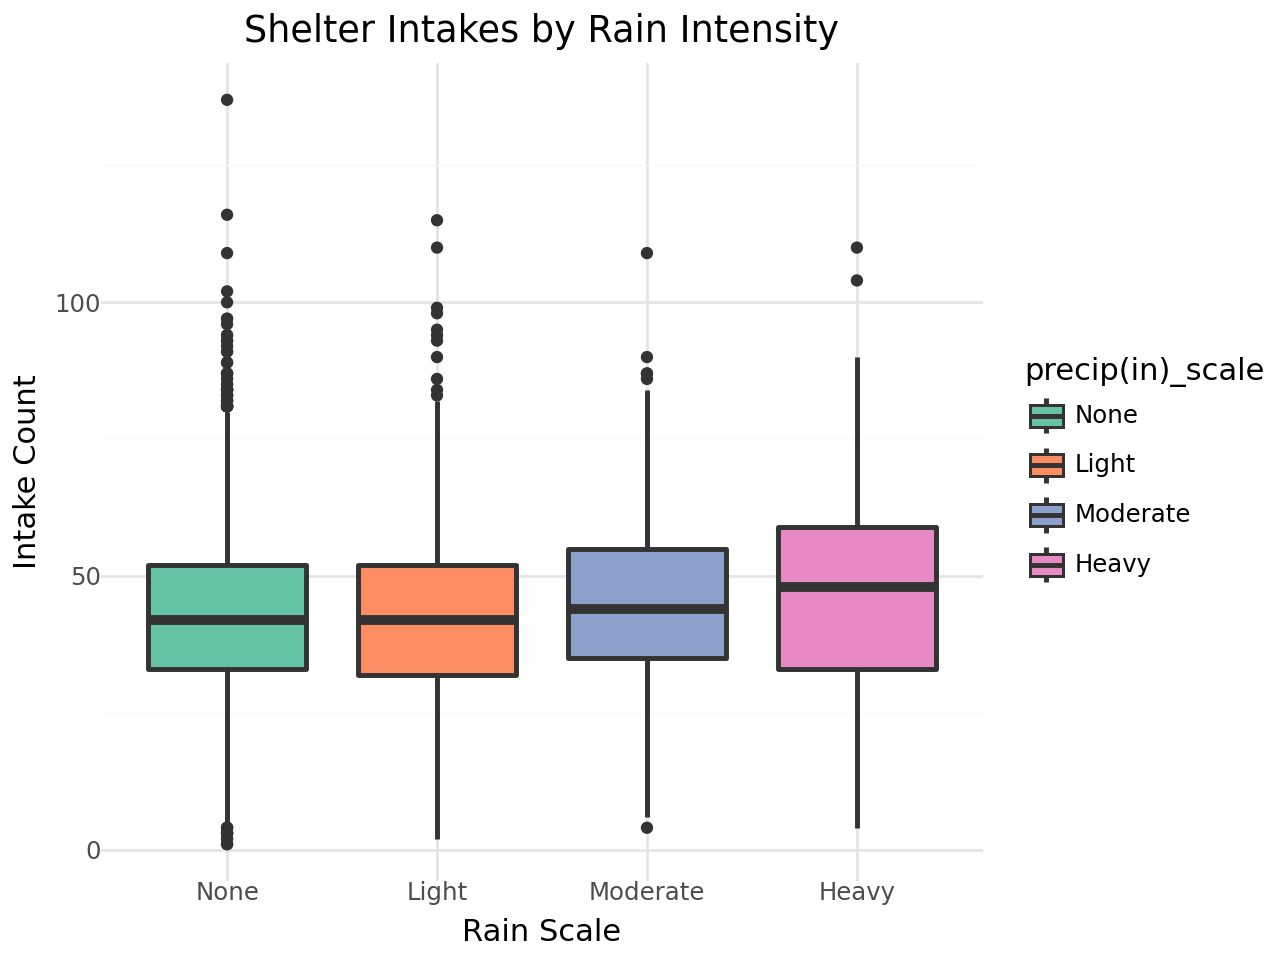

In [27]:
plot_weather_boxplot(df = weather_y_apts_per_day, 
                     x_axis = 'precip(in)', 
                     y_axis = 'apt_seen', 
                     bins = [-0.001, 0, 0.1, 0.5, np.inf], 
                     labels = ['None', 'Light', 'Moderate', 'Heavy'], 
                     title_text = 'Shelter Intakes by Rain Intensity', 
                     x_label_text = 'Rain Scale')

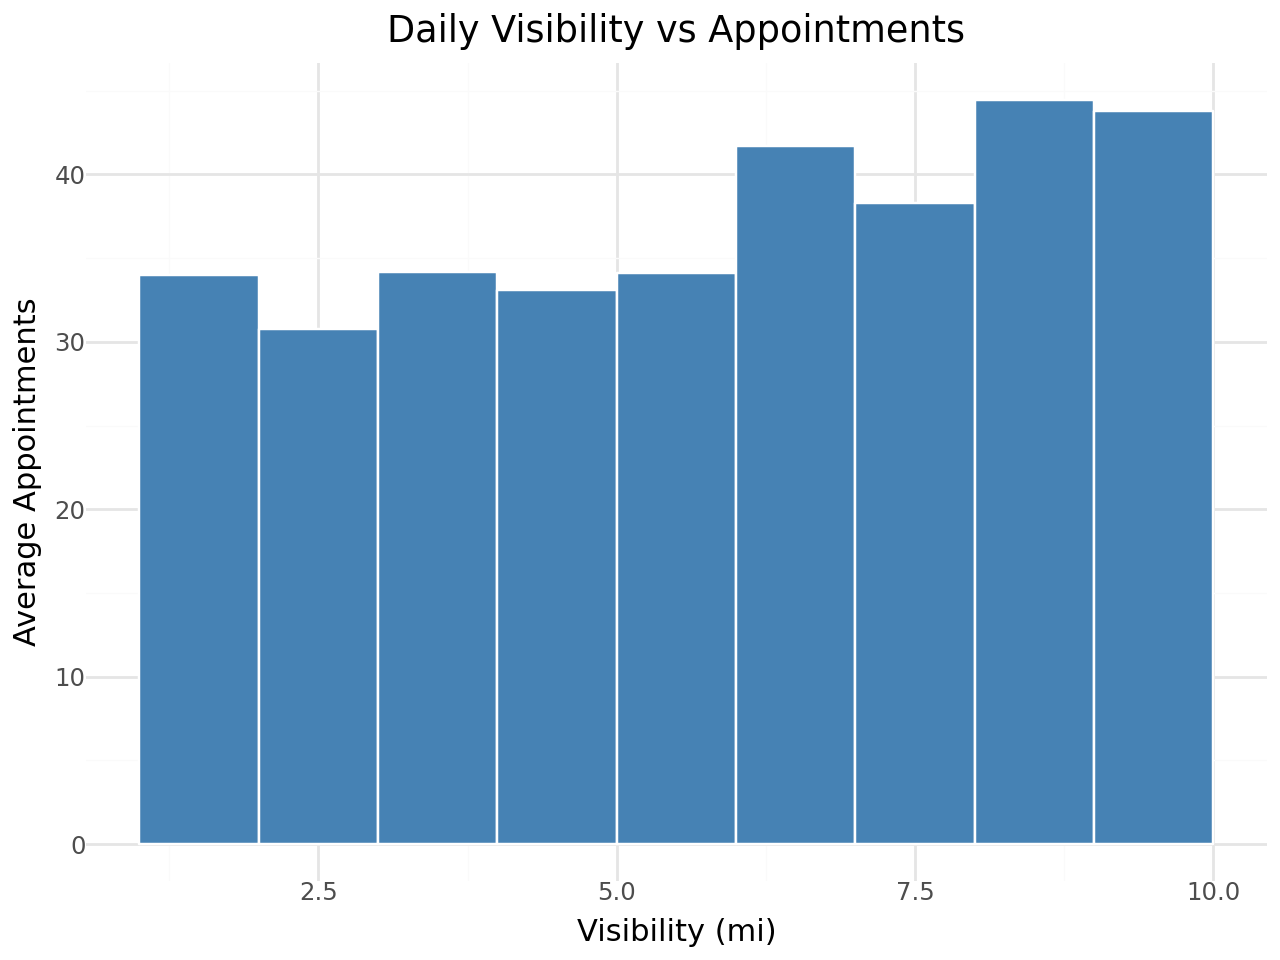

In [28]:
plot_factor_vs_appointments(
    weather_y_apts_per_day, 
    x_axis = 'visibility(mi)', 
    y_axis = 'apt_seen',
    x_label_text = 'Visibility (mi)',
    y_label_text = 'Average Appointments',
    title_text = 'Daily Visibility vs Appointments',
    bin_size = 1
)

In [29]:
run_pairwise_wilcoxon(
    df=weather_y_apts_per_day,
    x_axis='visibility(mi)',       # Replace with your exact column name if spelled differently
    y_axis='apt_seen',
    bins=[-0.001, 1, 4, 9, np.inf],  # Cut boundaries matching global weather metrics
    labels=['Dense Fog (<1mi)', 'Haze/Mist (1-4mi)', 'Moderate (4-9mi)', 'Clear Sky (>9mi)'],
    title_text='Atmospheric Visibility'
)


--- Pairwise Wilcoxon Rank Sum Test (Atmospheric Visibility) ---
Comparison                                    | p-value (Adjusted)  
----------------------------------------------------------------------
Haze/Mist (1-4mi) vs Moderate (4-9mi)         | 0.12649             
Haze/Mist (1-4mi) vs Clear Sky (>9mi)         | 0.01282             
Moderate (4-9mi) vs Clear Sky (>9mi)          | 0.01162             
----------------------------------------------------------------------


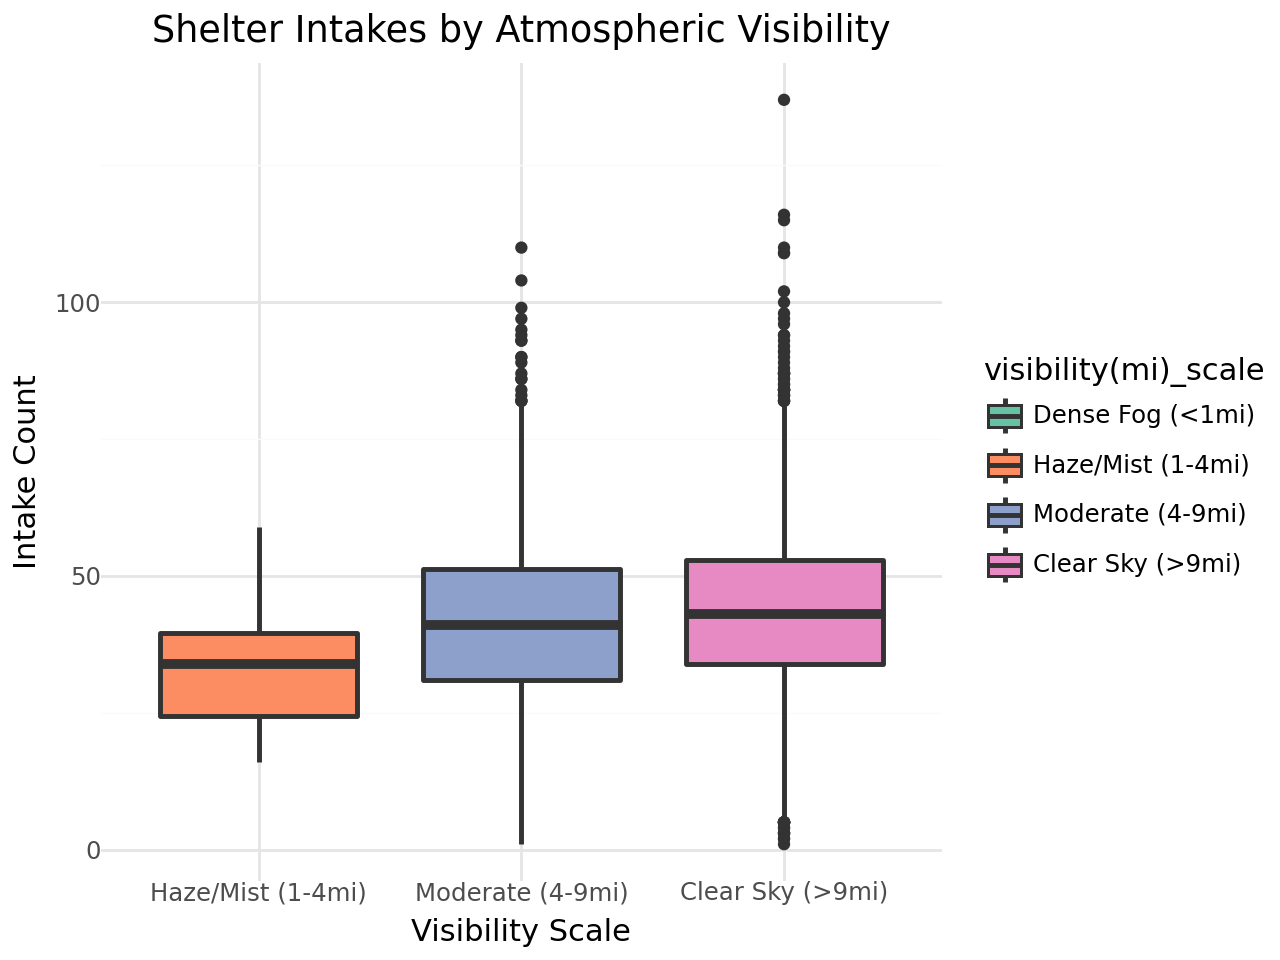

In [30]:
plot_weather_boxplot(df = weather_y_apts_per_day, 
                     x_axis = 'visibility(mi)', 
                     y_axis = 'apt_seen', 
                     bins = [-0.001, 1, 4, 9, np.inf], 
                     labels = ['Dense Fog (<1mi)', 'Haze/Mist (1-4mi)', 'Moderate (4-9mi)', 'Clear Sky (>9mi)'], 
                     title_text = 'Shelter Intakes by Atmospheric Visibility', 
                     x_label_text = 'Visibility Scale')

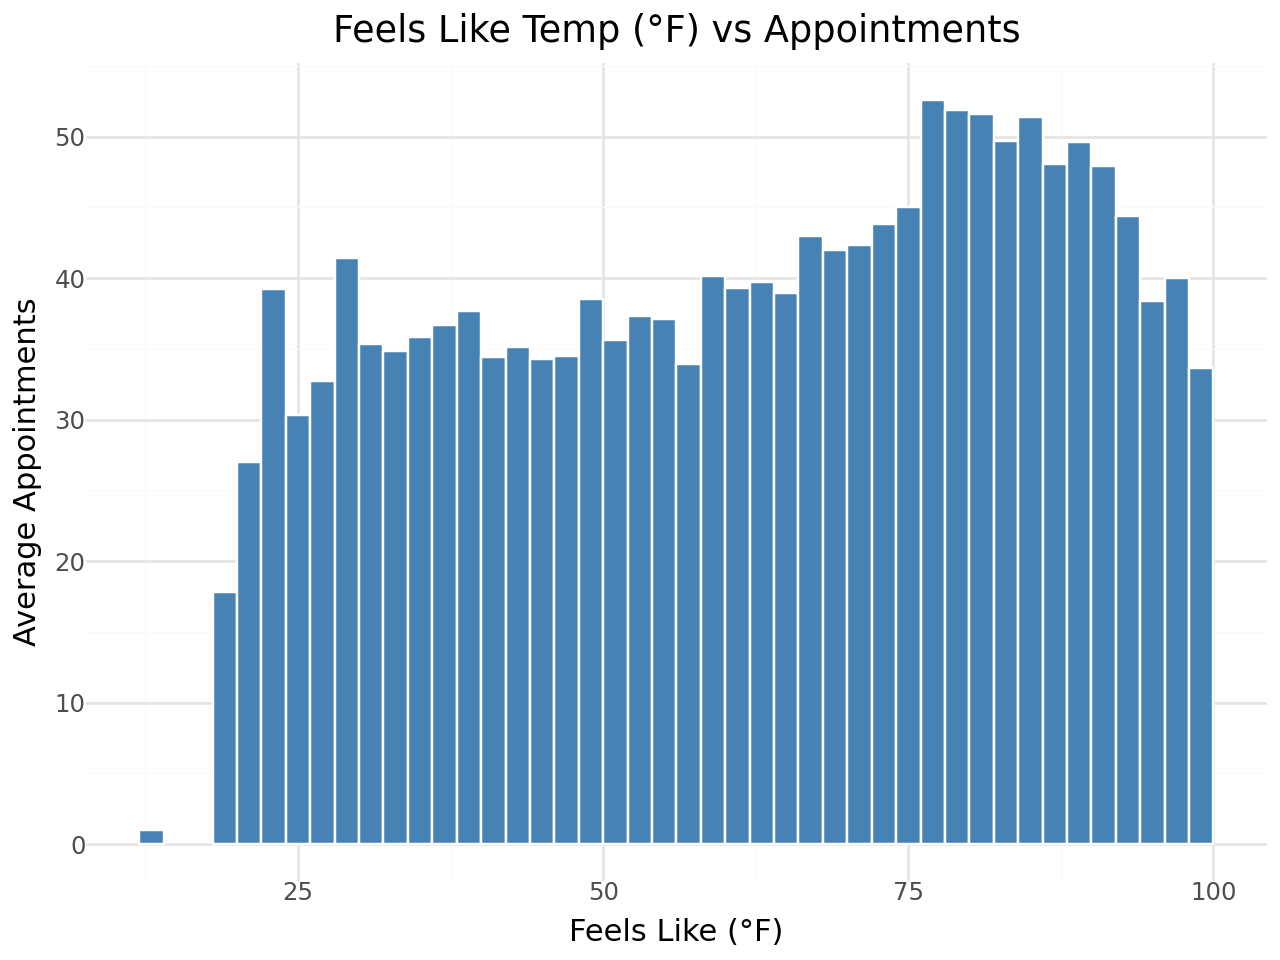

In [31]:
plot_factor_vs_appointments(
    weather_y_apts_per_day,
    x_axis='feels_like(°F)',
    y_axis='apt_seen',
    x_label_text='Feels Like (°F)',
    y_label_text='Average Appointments',
    title_text='Feels Like Temp (°F) vs Appointments',
    bin_size = 2 
)


In [32]:
run_pairwise_wilcoxon(
    df=weather_y_apts_per_day,
    x_axis='feels_like(°F)',
    y_axis='apt_seen',
    bins=[-np.inf, 20, 40, 60, 80, 100, np.inf],
    labels=['< 20°F', '20 - 40°F', '40 - 60°F', '60 - 80°F', '80 - 100°F', '> 100°F'],
    title_text='Feels Like Temperature'
)


--- Pairwise Wilcoxon Rank Sum Test (Feels Like Temperature) ---
Comparison                                    | p-value (Adjusted)  
----------------------------------------------------------------------
< 20°F vs 20 - 40°F                           | 0.01129             
< 20°F vs 40 - 60°F                           | 0.00913             
< 20°F vs 60 - 80°F                           | 0.00441             
< 20°F vs 80 - 100°F                          | 0.00229             
20 - 40°F vs 40 - 60°F                        | 1.00000             
20 - 40°F vs 60 - 80°F                        | 1.69056e-07         
20 - 40°F vs 80 - 100°F                       | 6.94981e-17         
40 - 60°F vs 60 - 80°F                        | 6.88957e-19         
40 - 60°F vs 80 - 100°F                       | 1.70293e-45         
60 - 80°F vs 80 - 100°F                       | 8.69710e-11         
----------------------------------------------------------------------


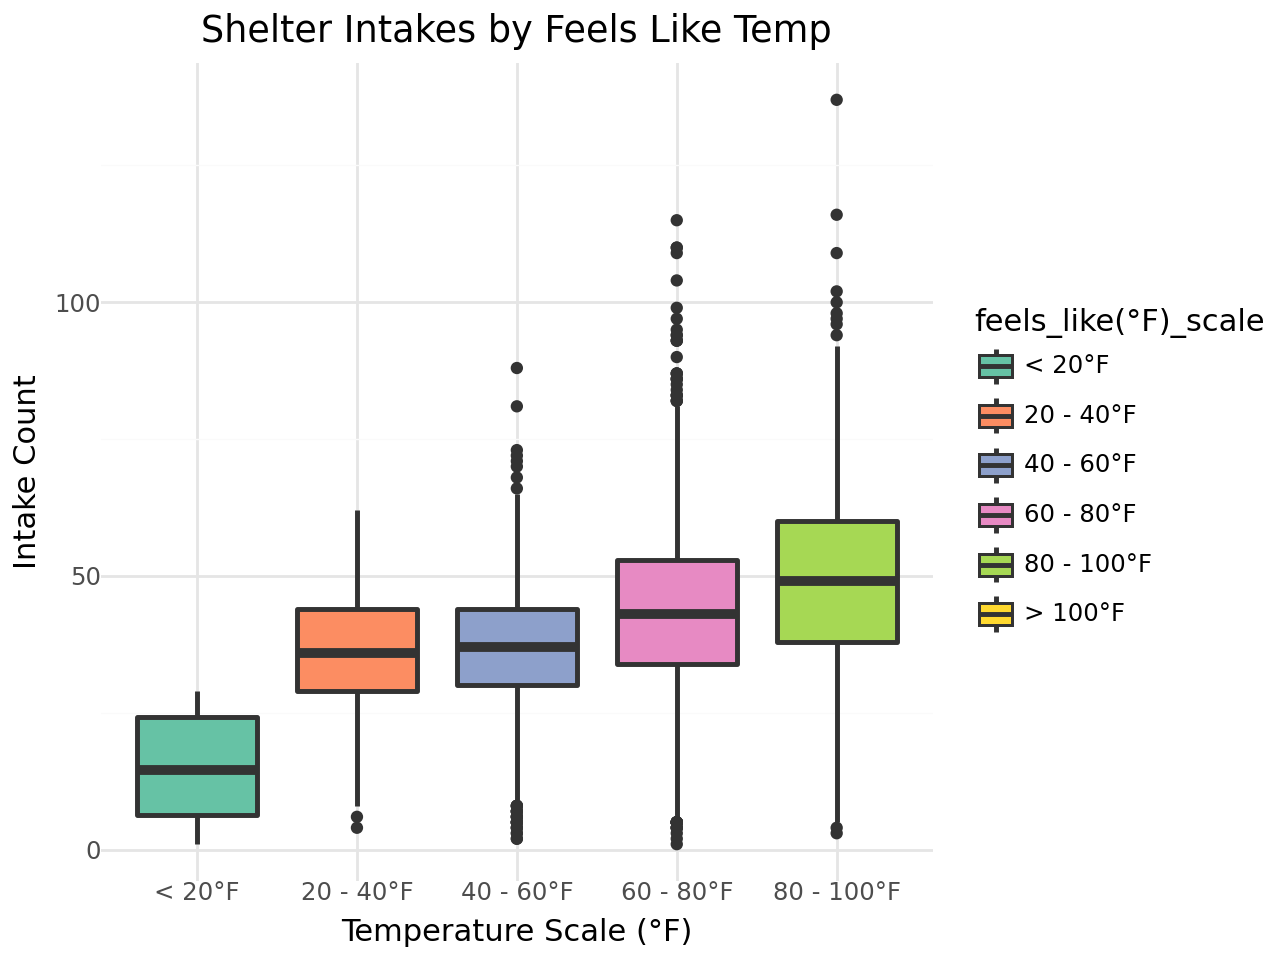

In [33]:
plot_weather_boxplot(weather_y_apts_per_day, 
                     x_axis = 'feels_like(°F)', 
                     y_axis = 'apt_seen', 
                     bins = [-np.inf, 20, 40, 60, 80, 100, np.inf], 
                     labels = ['< 20°F', '20 - 40°F', '40 - 60°F', '60 - 80°F', '80 - 100°F', '> 100°F'], 
                     title_text = 'Shelter Intakes by Feels Like Temp', 
                     x_label_text = 'Temperature Scale (°F)')

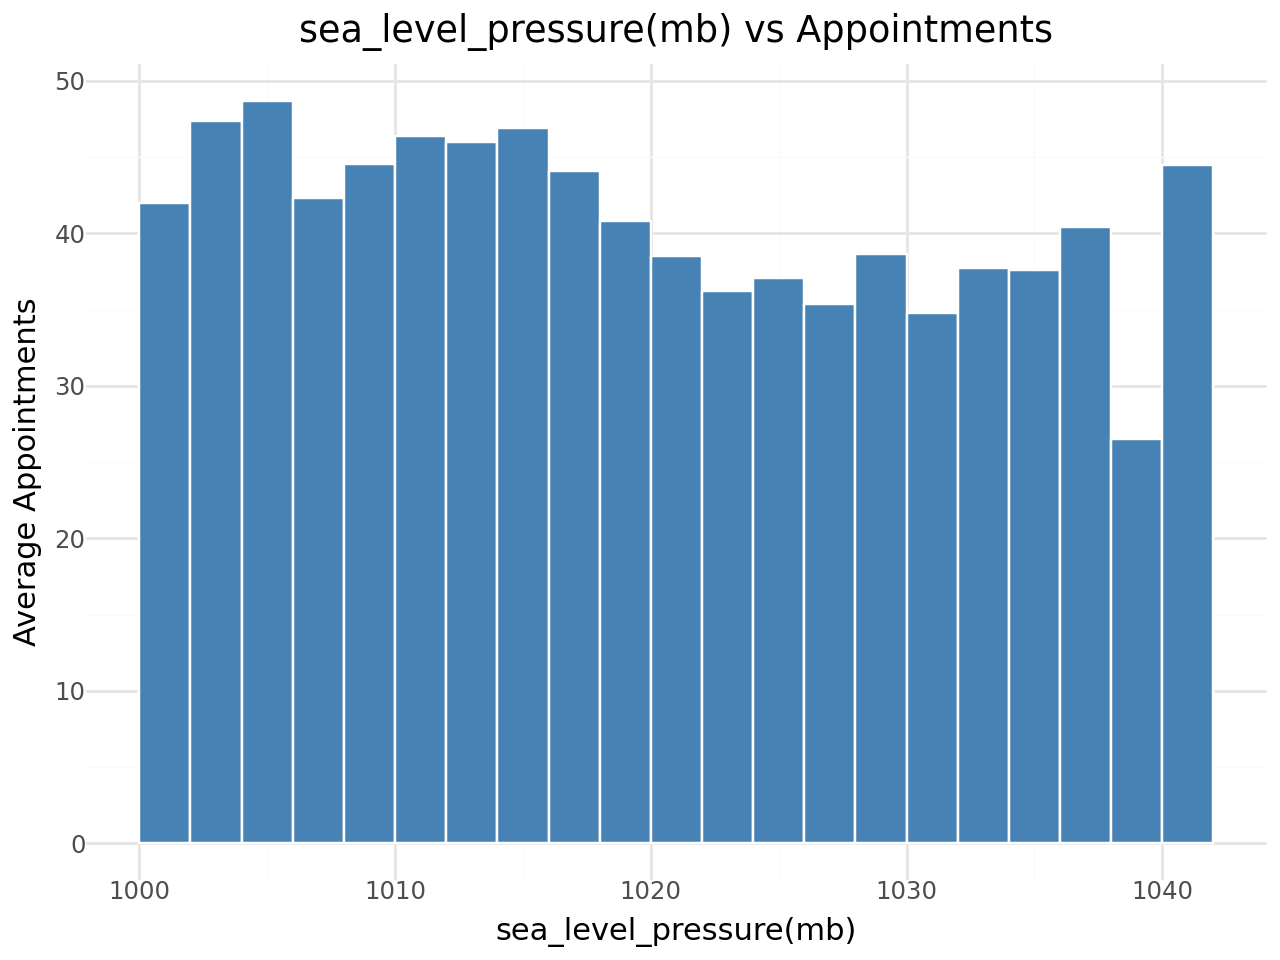

In [34]:
plot_factor_vs_appointments(
    weather_y_apts_per_day, 
    x_axis = 'sea_level_pressure(mb)', 
    y_axis = 'apt_seen',
    x_label_text = 'sea_level_pressure(mb)',
    y_label_text = 'Average Appointments',
    title_text = 'sea_level_pressure(mb) vs Appointments',
    bin_size = 2
)

In [35]:
run_pairwise_wilcoxon(
    df=weather_y_apts_per_day,
    x_axis='sea_level_pressure(mb)',
    y_axis='apt_seen',
    bins=[-np.inf, 1000, 1020, 1030, 1040, np.inf],
    labels=['< 1000', '1000 - 1020', '1020 - 1030', '1030 - 1040', '> 1040'],
    title_text='Barometric Pressure'
)


--- Pairwise Wilcoxon Rank Sum Test (Barometric Pressure) ---
Comparison                                    | p-value (Adjusted)  
----------------------------------------------------------------------
1000 - 1020 vs 1020 - 1030                    | 2.58603e-23         
1000 - 1020 vs 1030 - 1040                    | 7.94319e-06         
1000 - 1020 vs > 1040                         | 1.00000             
1020 - 1030 vs 1030 - 1040                    | 1.00000             
1020 - 1030 vs > 1040                         | 1.00000             
1030 - 1040 vs > 1040                         | 1.00000             
----------------------------------------------------------------------


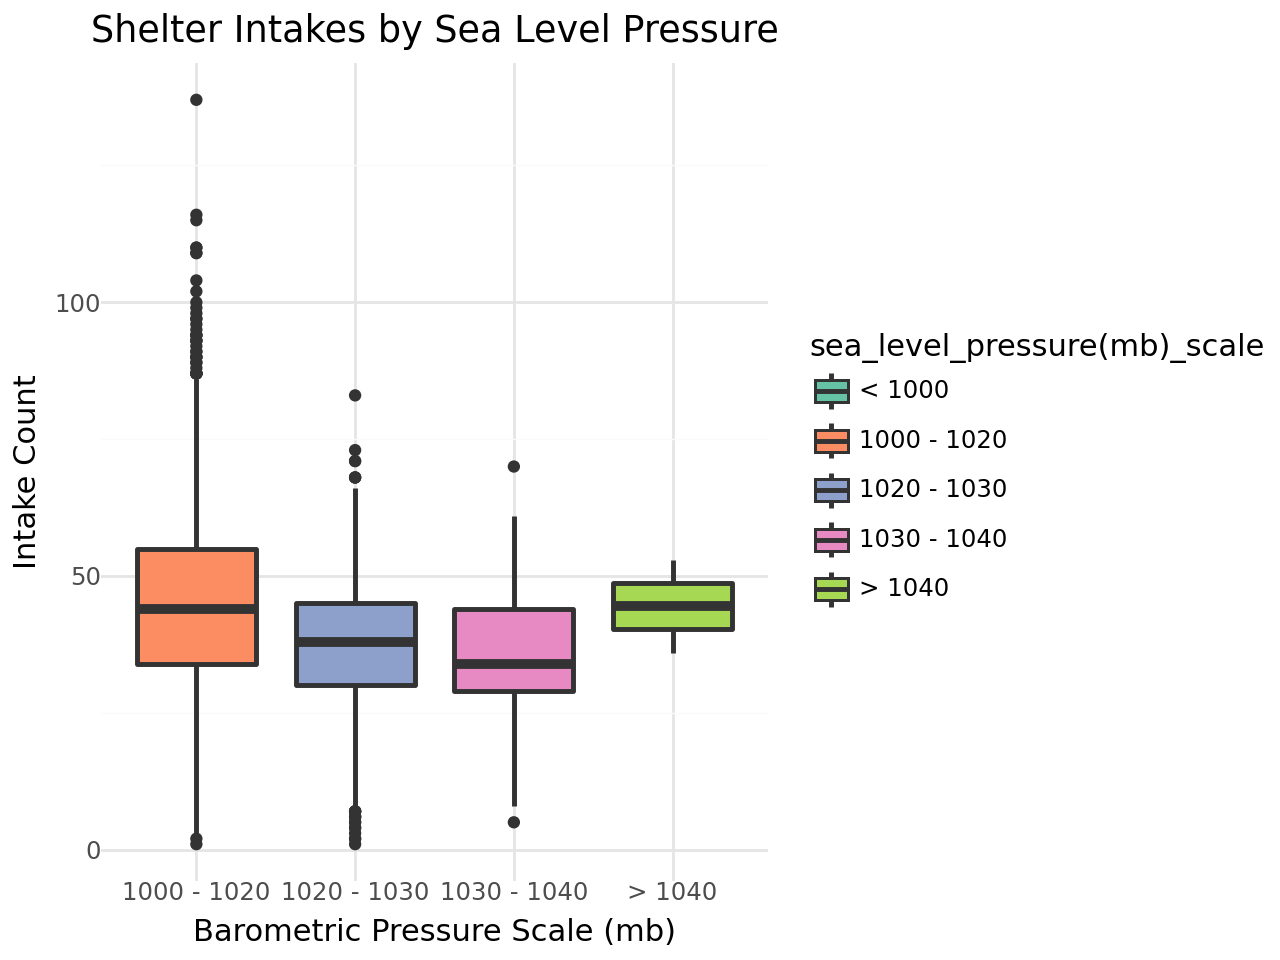

In [36]:
plot_weather_boxplot(df = weather_y_apts_per_day, 
                     x_axis = 'sea_level_pressure(mb)', 
                     y_axis = 'apt_seen', 
                     bins = [-np.inf, 1000, 1020, 1030, 1040, np.inf], 
                     labels = ['< 1000', '1000 - 1020', '1020 - 1030', '1030 - 1040', '> 1040'], 
                     title_text = 'Shelter Intakes by Sea Level Pressure', 
                     x_label_text = 'Barometric Pressure Scale (mb)')

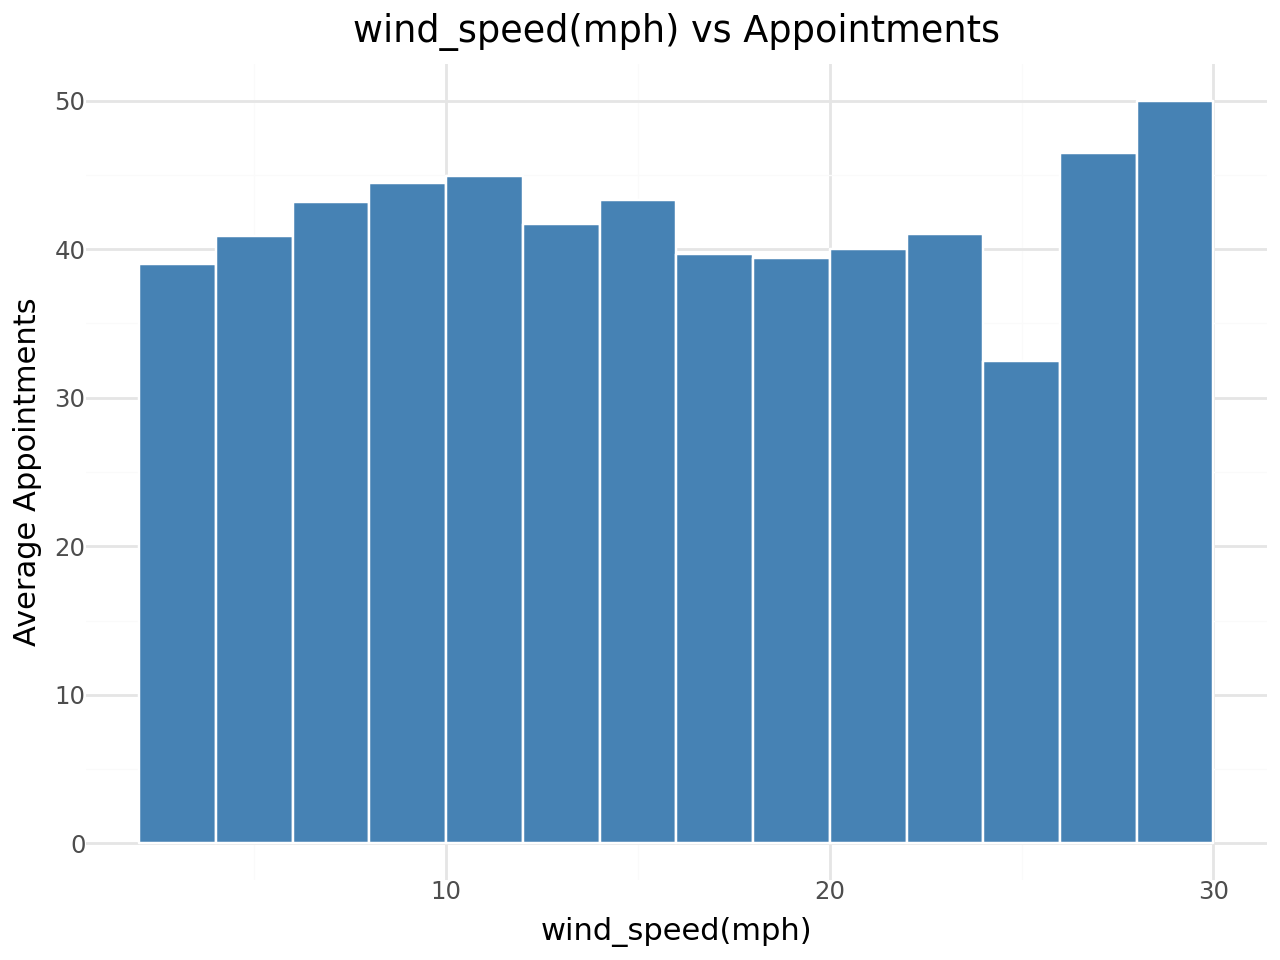

In [37]:
plot_factor_vs_appointments(
    weather_y_apts_per_day, 
    x_axis = 'wind_speed(mph)', 
    y_axis = 'apt_seen',
    x_label_text = 'wind_speed(mph)',
    y_label_text = 'Average Appointments',
    title_text = 'wind_speed(mph) vs Appointments',
    bin_size = 2
)

In [38]:
run_pairwise_wilcoxon(
    df=weather_y_apts_per_day,
    x_axis='wind_speed(mph)',
    y_axis='apt_seen',
    bins=[-0.001, 5, 10, 15, 20, 25, np.inf],
    labels=['Calm (<5mph)', 'Light (5-10mph)', 'Moderate (10-15mph)', 'Breezy (15-20mph)', 'Blustery (20-25mph)', 'Storm (>25mph)'],
    title_text='Wind Speed Dynamics'
)


--- Pairwise Wilcoxon Rank Sum Test (Wind Speed Dynamics) ---
Comparison                                    | p-value (Adjusted)  
----------------------------------------------------------------------
Calm (<5mph) vs Light (5-10mph)               | 1.00000             
Calm (<5mph) vs Moderate (10-15mph)           | 1.00000             
Calm (<5mph) vs Breezy (15-20mph)             | 1.00000             
Calm (<5mph) vs Blustery (20-25mph)           | 1.00000             
Calm (<5mph) vs Storm (>25mph)                | 1.00000             
Light (5-10mph) vs Moderate (10-15mph)        | 1.00000             
Light (5-10mph) vs Breezy (15-20mph)          | 0.11226             
Light (5-10mph) vs Blustery (20-25mph)        | 1.00000             
Light (5-10mph) vs Storm (>25mph)             | 1.00000             
Moderate (10-15mph) vs Breezy (15-20mph)      | 0.48674             
Moderate (10-15mph) vs Blustery (20-25mph)    | 1.00000             
Moderate (10-15mph) vs Storm (>25mph)  

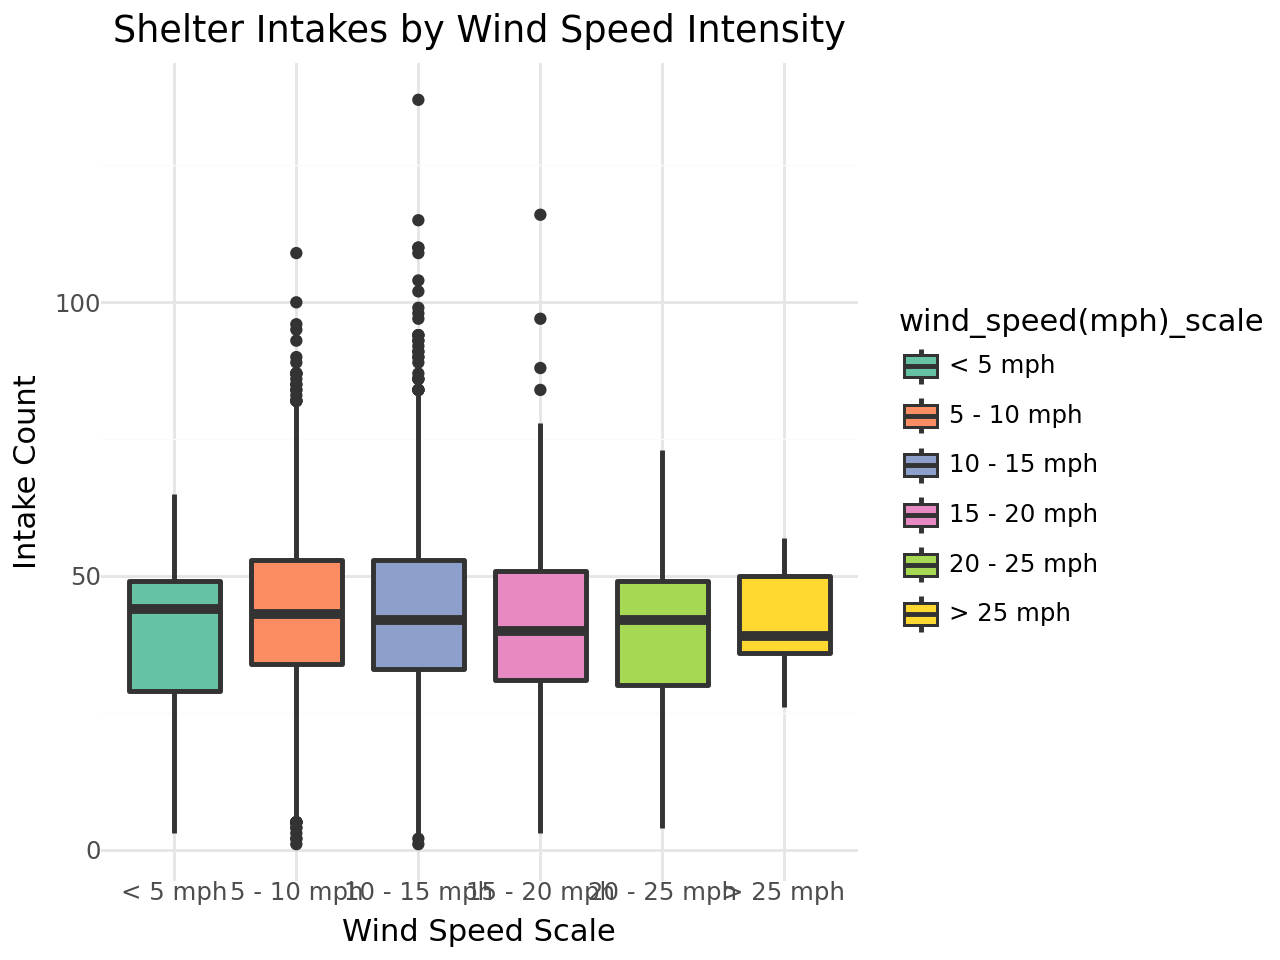

In [39]:
plot_weather_boxplot(df = weather_y_apts_per_day, 
                     x_axis = 'wind_speed(mph)', 
                     y_axis = 'apt_seen', 
                     bins = [-0.001, 5, 10, 15, 20, 25, np.inf],
                     labels = ['< 5 mph', '5 - 10 mph', '10 - 15 mph', '15 - 20 mph', '20 - 25 mph', '> 25 mph'], 
                     title_text = 'Shelter Intakes by Wind Speed Intensity', 
                     x_label_text = 'Wind Speed Scale')

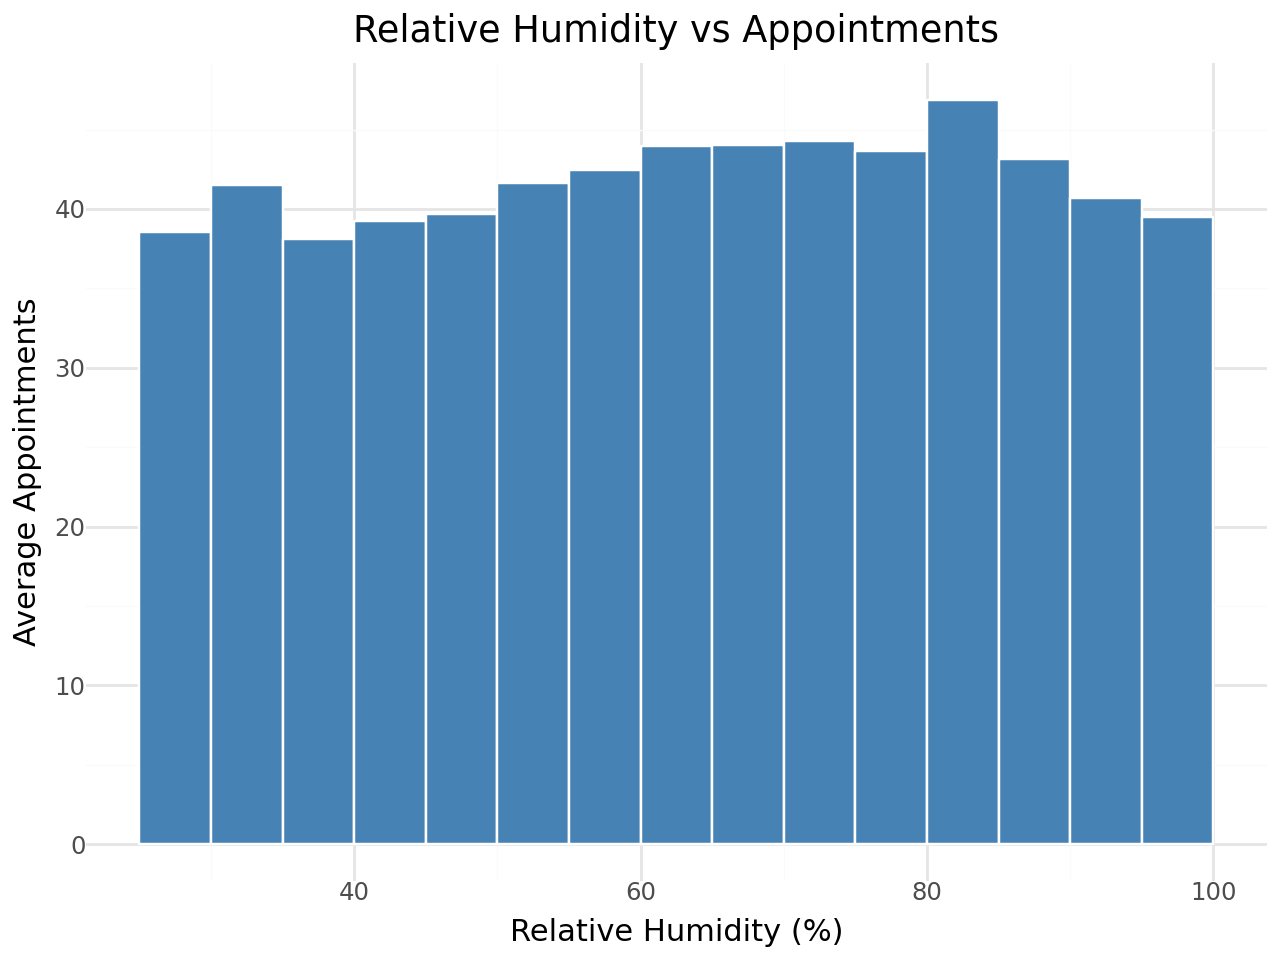

In [40]:
plot_factor_vs_appointments(
    weather_y_apts_per_day,
    x_axis='humidity(%)',                 
    y_axis='apt_seen',
    x_label_text='Relative Humidity (%)',
    y_label_text='Average Appointments',
    title_text='Relative Humidity vs Appointments',
    bin_size=5                         
)


In [41]:
run_pairwise_wilcoxon(
    df=weather_y_apts_per_day,
    x_axis='humidity(%)',                 
    y_axis='apt_seen',
    bins=[-0.001, 40, 60, 80, np.inf],  
    labels=['Dry (<40%)', 'Comfortable (40-60%)', 'Humid (60-80%)', 'Oppressive (>80%)'],
    title_text='Relative Humidity Zones'
)


--- Pairwise Wilcoxon Rank Sum Test (Relative Humidity Zones) ---
Comparison                                    | p-value (Adjusted)  
----------------------------------------------------------------------
Dry (<40%) vs Comfortable (40-60%)            | 1.00000             
Dry (<40%) vs Humid (60-80%)                  | 0.05919             
Dry (<40%) vs Oppressive (>80%)               | 0.22647             
Comfortable (40-60%) vs Humid (60-80%)        | 0.00216             
Comfortable (40-60%) vs Oppressive (>80%)     | 0.19999             
Humid (60-80%) vs Oppressive (>80%)           | 1.00000             
----------------------------------------------------------------------


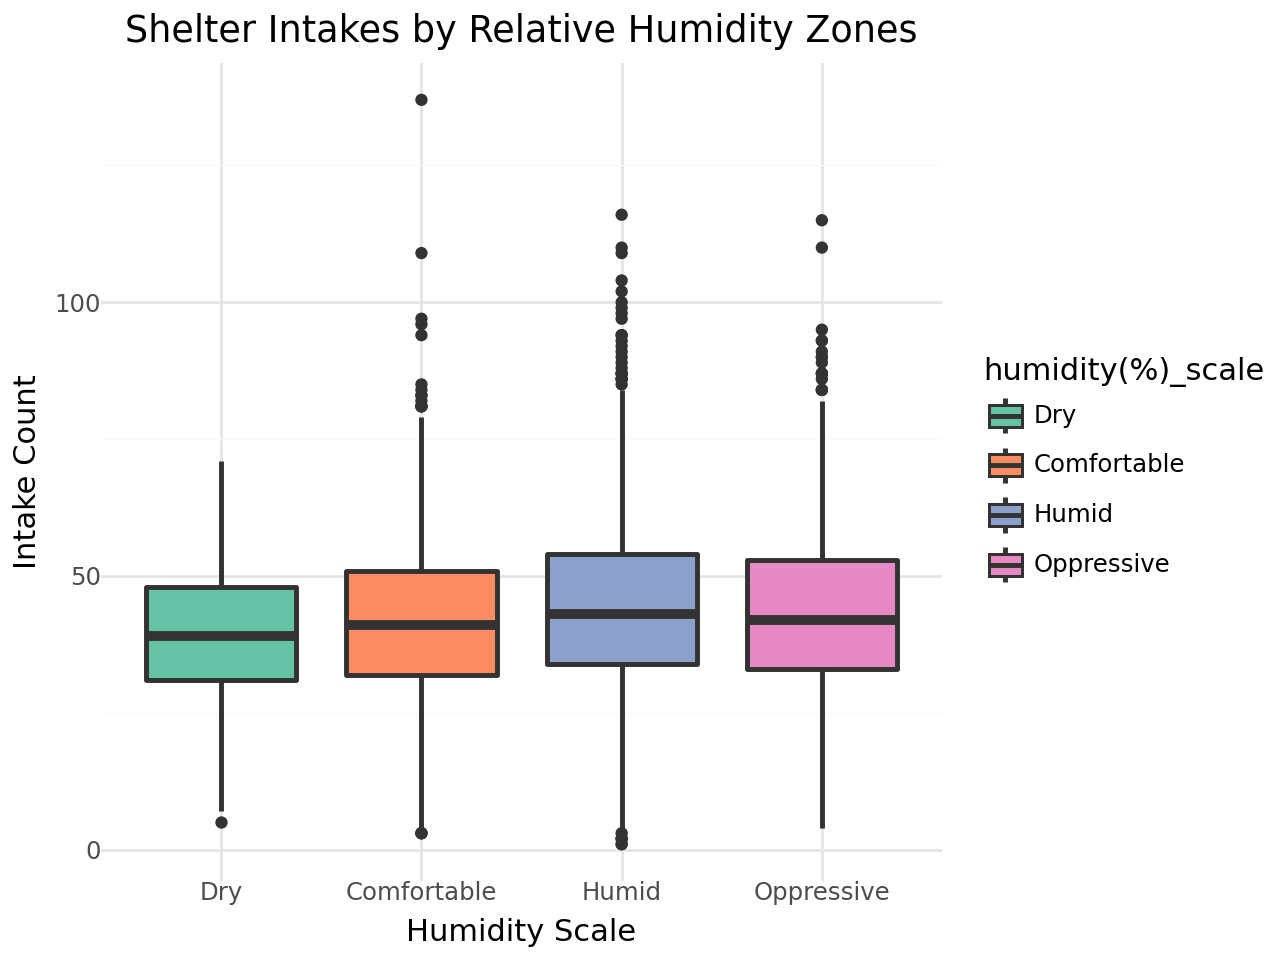

In [42]:
plot_weather_boxplot(df = weather_y_apts_per_day, 
                     x_axis = 'humidity(%)', 
                     y_axis = 'apt_seen', 
                     bins = [-0.001, 40, 60, 80, np.inf],
                     labels = ['Dry', 'Comfortable', 'Humid', 'Oppressive'], 
                     title_text = 'Shelter Intakes by Relative Humidity Zones', 
                     x_label_text = 'Humidity Scale')

In [43]:
!pip freeze > requirements.txt